In [1]:
import torch
import torch.nn as nn
import numpy as np
import random

In [2]:
from rdflib import Graph, URIRef
from urllib.parse import urlparse
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

#### Part2

1.1

In [3]:
from rdflib import Graph

g = Graph()
g.parse("movie_kb_final.nt", format="nt")
print(f"Total triples: {len(g)}")

Total triples: 61809


1.2

In [4]:
# 1. Retain only URI triples, filter out literals
clean_triples = []
for s, p, o in g:
    if isinstance(s, URIRef) and isinstance(p, URIRef) and isinstance(o, URIRef):
        clean_triples.append((str(s), str(p), str(o)))
print(f"After literal filter: {len(clean_triples)}")

# 2. Remove duplicates
clean_triples = list(set(clean_triples))
print(f"After dedup: {len(clean_triples)}")

# 3. Filter inconsistent URIs
def is_valid_uri(uri):
    try:
        result = urlparse(uri)
        return all([result.scheme, result.netloc])
    except:
        return False

before = len(clean_triples)
clean_triples = [(s, p, o) for s, p, o in clean_triples
                 if is_valid_uri(s) and is_valid_uri(p) and is_valid_uri(o)]
print(f"After URI validation: {len(clean_triples)} (removed {before - len(clean_triples)})")

# 4. Create unique indices
entities  = sorted(set([s for s,p,o in clean_triples] + [o for s,p,o in clean_triples]))
relations = sorted(set([p for s,p,o in clean_triples]))

entity2id   = {e: i for i, e in enumerate(entities)}
relation2id = {r: i for i, r in enumerate(relations)}

print(f"Unique entities:  {len(entities)}")
print(f"Unique relations: {len(relations)}")

After literal filter: 56418
After dedup: 56418
After URI validation: 56122 (removed 296)
Unique entities:  22402
Unique relations: 12


1.3

In [5]:
random.seed(42)
random.shuffle(clean_triples)

n= len(clean_triples)
train_end = int(n * 0.8)
valid_end = int(n * 0.9)

train = clean_triples[:train_end]
valid = clean_triples[train_end:valid_end]
test  = clean_triples[valid_end:]

In [6]:
# Move tuples containing unseen entities from `valid/test` to `train`
def fix_split(train, valid, test):
    train_entities = set([s for s,p,o in train] + [o for s,p,o in train])
    new_valid = []
    for triple in valid:
        s, p, o = triple
        if s in train_entities and o in train_entities:
            new_valid.append(triple)
        else:
            train.append(triple)
            train_entities.add(s)
            train_entities.add(o)
    new_test = []
    for triple in test:
        s, p, o = triple
        if s in train_entities and o in train_entities:
            new_test.append(triple)
        else:
            train.append(triple)
            train_entities.add(s)
            train_entities.add(o)
    return train, new_valid, new_test

train, valid, test = fix_split(train, valid, test)

print(f"Train: {len(train)}")
print(f"Valid: {len(valid)}")
print(f"Test:  {len(test)}")

#Valid
train_entities = set([s for s,p,o in train] + [o for s,p,o in train])
valid_entities = set([s for s,p,o in valid] + [o for s,p,o in valid])
test_entities  = set([s for s,p,o in test]  + [o for s,p,o in test])

print(f"Entities only in valid: {len(valid_entities - train_entities)}")
print(f"Entities only in test:  {len(test_entities  - train_entities)}")


Train: 45714
Valid: 5047
Test:  5361
Entities only in valid: 0
Entities only in test:  0


In [7]:
def save_triples(triples, path):
    with open(path, "w") as f:
        for s, p, o in triples:
            f.write(f"{s}\t{p}\t{o}\n")

save_triples(train, "train.txt")
save_triples(valid, "valid.txt")
save_triples(test,  "test.txt")

2

In [8]:
%pip install torchkge

Note: you may need to restart the kernel to use updated packages.


In [9]:
import torch
from torchkge.models import TransEModel
from torchkge.sampling import BernoulliNegativeSampler
from torchkge.utils import MarginLoss, DataLoader
from torchkge.data_structures import KnowledgeGraph
import pandas as pd

#Load Data
def load_triples(path):
    df = pd.read_csv(path, sep="\t", header=None, names=["from", "rel", "to"])
    return df

train_df = load_triples("train.txt")
valid_df = load_triples("valid.txt")
test_df  = load_triples("test.txt")

print(f"Train: {len(train_df)}, Valid: {len(valid_df)}, Test: {len(test_df)}")

#build KnowledgeGraph
kg_train = KnowledgeGraph(df=train_df)
kg_valid = KnowledgeGraph(df=valid_df, ent2ix=kg_train.ent2ix, rel2ix=kg_train.rel2ix)
kg_test  = KnowledgeGraph(df=test_df,  ent2ix=kg_train.ent2ix, rel2ix=kg_train.rel2ix)

print(f"Entities: {kg_train.n_ent}, Relations: {kg_train.n_rel}")

Train: 45714, Valid: 5047, Test: 5361


/Users/hanwang/Desktop/4下/.venv/lib/python3.9/site-packages/torchkge/utils/data_redundancy.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


Entities: 22402, Relations: 12


2+3

In [10]:
%pip install ampligraph
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [11]:
import ampligraph
print(ampligraph.__version__)

/Users/hanwang/Desktop/4下/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


2.1.0


TransE

In [12]:
import numpy as np
from ampligraph.datasets import load_from_csv
from ampligraph.latent_features import ScoringBasedEmbeddingModel

train = load_from_csv(".", "train.txt", sep="\t")
valid = load_from_csv(".", "valid.txt", sep="\t")
test  = load_from_csv(".", "test.txt",  sep="\t")

print(f"Train: {len(train)}")
print(f"Valid: {len(valid)}")
print(f"Test:  {len(test)}")
print(f"Example triple: {train[0]}")

Train: 45714
Valid: 5047
Test:  5361
Example triple: ['http://www.wikidata.org/entity/Q519490'
 'http://moviekg.local/ontology/hasActor'
 'http://www.wikidata.org/entity/Q3454165']


In [13]:
import torch
import torch.nn as nn
import numpy as np
import random

#Use only `train` to build the index
entities  = sorted(set([s for s,p,o in train] + [o for s,p,o in train]))
relations = sorted(set([p for s,p,o in train]))

entity2id   = {e: i for i, e in enumerate(entities)}
relation2id = {r: i for i, r in enumerate(relations)}

def triples_to_ids(triples):
    result = []
    for s, p, o in triples:
        if s in entity2id and o in entity2id and p in relation2id:
            result.append((entity2id[s], relation2id[p], entity2id[o]))
    return result

train_ids = triples_to_ids(train)
valid_ids = triples_to_ids(valid)
test_ids  = triples_to_ids(test)

print(f"Entities: {len(entity2id)}, Relations: {len(relation2id)}")
print(f"Train: {len(train_ids)}, Valid: {len(valid_ids)}, Test: {len(test_ids)}")

Entities: 22402, Relations: 12
Train: 45714, Valid: 5047, Test: 5361


In [14]:
class TransE(nn.Module):
    def __init__(self, n_entities, n_relations, dim=100, margin=1.0):
        super(TransE, self).__init__()
        self.dim = dim
        self.margin = margin
        
        # Embedding of Entities and Relationships
        self.entity_emb   = nn.Embedding(n_entities, dim)
        self.relation_emb = nn.Embedding(n_relations, dim)
        
        # Initialize
        nn.init.uniform_(self.entity_emb.weight,   -6/dim**0.5, 6/dim**0.5)
        nn.init.uniform_(self.relation_emb.weight, -6/dim**0.5, 6/dim**0.5)
    
    def forward(self, pos, neg):
        # pos/neg: (batch, 3) -> [s, p, o]
        pos_s = self.entity_emb(pos[:, 0])
        pos_p = self.relation_emb(pos[:, 1])
        pos_o = self.entity_emb(pos[:, 2])
        
        neg_s = self.entity_emb(neg[:, 0])
        neg_p = self.relation_emb(neg[:, 1])
        neg_o = self.entity_emb(neg[:, 2])
        
        # Caculate distance
        pos_score = torch.norm(pos_s + pos_p - pos_o, p=1, dim=1)
        neg_score = torch.norm(neg_s + neg_p - neg_o, p=1, dim=1)
        
        # Margin loss
        loss = torch.relu(self.margin + pos_score - neg_score).mean()
        return loss
    
    def get_embeddings(self):
        return self.entity_emb.weight.detach(), self.relation_emb.weight.detach()

print("TransE model defined!")

TransE model defined!


In [15]:
def negative_sampling(batch, n_entities):
    neg = batch.clone()
    for i in range(len(batch)):
        if random.random() > 0.5:
            neg[i, 0] = random.randint(0, n_entities - 1)  # 替换subject
        else:
            neg[i, 2] = random.randint(0, n_entities - 1)  # 替换object
    return neg

# Train param
dim        = 100
margin     = 1.0
lr         = 0.01
batch_size = 512
epochs     = 50
n_entities  = len(entity2id)
n_relations = len(relation2id)

model     = TransE(n_entities, n_relations, dim, margin)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_tensor = torch.tensor(train_ids, dtype=torch.long)

# Train
for epoch in range(epochs):
    model.train()
    random.shuffle(train_ids)
    train_tensor = torch.tensor(train_ids, dtype=torch.long)
    
    total_loss = 0
    for i in range(0, len(train_tensor), batch_size):
        batch = train_tensor[i:i+batch_size]
        neg   = negative_sampling(batch, n_entities)
        
        optimizer.zero_grad()
        loss = model(batch, neg)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")


Epoch 10/50, Loss: 50.2992
Epoch 20/50, Loss: 47.6124
Epoch 30/50, Loss: 45.9026
Epoch 40/50, Loss: 46.1527
Epoch 50/50, Loss: 48.7513


Dist Mult

In [16]:
class DistMult(nn.Module):
    def __init__(self, n_entities, n_relations, dim=100):
        super(DistMult, self).__init__()
        self.entity_emb   = nn.Embedding(n_entities, dim)
        self.relation_emb = nn.Embedding(n_relations, dim)
        
        nn.init.uniform_(self.entity_emb.weight,   -0.1, 0.1)
        nn.init.uniform_(self.relation_emb.weight, -0.1, 0.1)
    
    def score(self, s, p, o):
        # DistMult: s * p * o 逐元素相乘再求和
        return (s * p * o).sum(dim=1)
    
    def forward(self, pos, neg):
        pos_s = self.entity_emb(pos[:, 0])
        pos_p = self.relation_emb(pos[:, 1])
        pos_o = self.entity_emb(pos[:, 2])
        
        neg_s = self.entity_emb(neg[:, 0])
        neg_p = self.relation_emb(neg[:, 1])
        neg_o = self.entity_emb(neg[:, 2])
        
        pos_score = self.score(pos_s, pos_p, pos_o)
        neg_score = self.score(neg_s, neg_p, neg_o)
        
        # Make the scores for positive samples high and the scores for negative samples low
        loss = torch.relu(1.0 - pos_score + neg_score).mean()
        return loss

# Train DistMult
model_distmult = DistMult(n_entities, n_relations, dim=100)
optimizer_dm   = torch.optim.Adam(model_distmult.parameters(), lr=0.01)

for epoch in range(50):
    model_distmult.train()
    random.shuffle(train_ids)
    train_tensor = torch.tensor(train_ids, dtype=torch.long)
    
    total_loss = 0
    for i in range(0, len(train_tensor), batch_size):
        batch = train_tensor[i:i+batch_size]
        neg   = negative_sampling(batch, n_entities)
        
        optimizer_dm.zero_grad()
        loss = model_distmult(batch, neg)
        loss.backward()
        optimizer_dm.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50, Loss: {total_loss:.4f}")

Epoch 10/50, Loss: 12.5590
Epoch 20/50, Loss: 12.1498
Epoch 30/50, Loss: 11.3092
Epoch 40/50, Loss: 11.2346
Epoch 50/50, Loss: 11.0040


4

In [17]:
def evaluate(model, test_ids, entity2id, relation2id, batch_size=128):
    model.eval()
    n_entities = len(entity2id)
    
    all_entities = torch.arange(n_entities, dtype=torch.long)
    
    ranks = []
    
    with torch.no_grad():
        for i, (s, p, o) in enumerate(test_ids[:500]):  #Only test first 500 to save the time
            s_t = torch.tensor(s)
            p_t = torch.tensor(p)
            o_t = torch.tensor(o)
            
            # Tail prediction: (s, p, ?)
            s_expand = s_t.expand(n_entities)
            p_expand = p_t.expand(n_entities)
            
            s_emb = model.entity_emb(s_expand)
            p_emb = model.relation_emb(p_expand)
            o_emb = model.entity_emb(all_entities)
            
            scores = torch.norm(s_emb + p_emb - o_emb, p=1, dim=1)
            rank   = (scores < scores[o_t]).sum().item() + 1
            ranks.append(rank)
        
        ranks = np.array(ranks)
        mrr     = np.mean(1.0 / ranks)
        hits1   = np.mean(ranks <= 1)
        hits3   = np.mean(ranks <= 3)
        hits10  = np.mean(ranks <= 10)
    
    print(f"MRR:     {mrr:.4f}")
    print(f"Hits@1:  {hits1:.4f}")
    print(f"Hits@3:  {hits3:.4f}")
    print(f"Hits@10: {hits10:.4f}")
    
    return mrr, hits1, hits3, hits10

print("TransE Evaluation")
mrr_t, h1_t, h3_t, h10_t = evaluate(model, test_ids, entity2id, relation2id)

TransE Evaluation
MRR:     0.1845
Hits@1:  0.0760
Hits@3:  0.2640
Hits@10: 0.3560


In [18]:
def evaluate_distmult(model, test_ids, entity2id, relation2id):
    model.eval()
    n_entities = len(entity2id)
    all_entities = torch.arange(n_entities, dtype=torch.long)
    
    ranks = []
    
    with torch.no_grad():
        for s, p, o in test_ids[:500]:
            s_t = torch.tensor(s)
            p_t = torch.tensor(p)
            o_t = torch.tensor(o)
            
            s_expand = s_t.expand(n_entities)
            p_expand = p_t.expand(n_entities)
            
            s_emb = model.entity_emb(s_expand)
            p_emb = model.relation_emb(p_expand)
            o_emb = model.entity_emb(all_entities)
            
            # A higher DistMult score is better, so “rank” refers to the number by which the score exceeds the correct answer.
            scores = (s_emb * p_emb * o_emb).sum(dim=1)
            rank   = (scores > scores[o_t]).sum().item() + 1
            ranks.append(rank)
    
    ranks  = np.array(ranks)
    mrr    = np.mean(1.0 / ranks)
    hits1  = np.mean(ranks <= 1)
    hits3  = np.mean(ranks <= 3)
    hits10 = np.mean(ranks <= 10)
    
    print(f"MRR:     {mrr:.4f}")
    print(f"Hits@1:  {hits1:.4f}")
    print(f"Hits@3:  {hits3:.4f}")
    print(f"Hits@10: {hits10:.4f}")
    
    return mrr, hits1, hits3, hits10

print("DistMult Evaluation")
mrr_dm, h1_dm, h3_dm, h10_dm = evaluate_distmult(model_distmult, test_ids, entity2id, relation2id)

DistMult Evaluation
MRR:     0.0343
Hits@1:  0.0260
Hits@3:  0.0340
Hits@10: 0.0480


5

5.1

TransE outperforms DistMult across all evaluation metrics. This can be attributed to the fact that most relations in the knowledge graph are asymmetric (e.g., hasDirector, hasActor), for which TransE’s translational mechanism is particularly well-suited.
In contrast, DistMult is inherently designed for symmetric relations, due to its bilinear scoring function, and therefore struggles to effectively model directional relationships. As a result, its performance on this dataset is comparatively weaker.


5.2

In [19]:
# 20k
train_20k = train_ids[:20000]
# 50kis the full train_ids

def train_transe(train_data, epochs=50, dim=100, batch_size=512):
    m = TransE(n_entities, n_relations, dim)
    opt = torch.optim.Adam(m.parameters(), lr=0.01)
    data = torch.tensor(train_data, dtype=torch.long)
    
    for epoch in range(epochs):
        m.train()
        total_loss = 0
        for i in range(0, len(data), batch_size):
            batch = data[i:i+batch_size]
            neg   = negative_sampling(batch, n_entities)
            opt.zero_grad()
            loss  = m(batch, neg)
            loss.backward()
            opt.step()
            total_loss += loss.item()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
    return m

print("Training with 20k triples")
model_20k = train_transe(train_20k)
print("\nEvaluating 20k")
evaluate(model_20k, test_ids, entity2id, relation2id)

Training with 20k triples
Epoch 10, Loss: 11.8792
Epoch 20, Loss: 9.1055
Epoch 30, Loss: 9.2177
Epoch 40, Loss: 8.4946
Epoch 50, Loss: 8.8504

Evaluating 20k
MRR:     0.0930
Hits@1:  0.0160
Hits@3:  0.1300
Hits@10: 0.2320


(0.09295026802060116, 0.016, 0.13, 0.232)

In [20]:
train_30k = train_ids[:30000]

print("Training with 30k triples")
model_30k = train_transe(train_30k)
print("\nEvaluating 30k")
evaluate(model_30k, test_ids, entity2id, relation2id)

Training with 30k triples
Epoch 10, Loss: 24.5908
Epoch 20, Loss: 19.3705
Epoch 30, Loss: 19.3519
Epoch 40, Loss: 19.4692
Epoch 50, Loss: 21.2308

Evaluating 30k
MRR:     0.1237
Hits@1:  0.0580
Hits@3:  0.1600
Hits@10: 0.2400


(0.1236724721991211, 0.058, 0.16, 0.24)

Here because after cleaning, the full train tripls have only 45k,so 50k eauqls to the full tripls, and I just added 30k here to compare.

In [21]:
print("\nTraining with full dataset (45k)")
model_full = train_transe(train_ids)
print("\nEvaluating full")
evaluate(model_full, test_ids, entity2id, relation2id)


Training with full dataset (45k)
Epoch 10, Loss: 52.0898
Epoch 20, Loss: 44.2349
Epoch 30, Loss: 45.8231
Epoch 40, Loss: 46.8645
Epoch 50, Loss: 47.0438

Evaluating full
MRR:     0.1094
Hits@1:  0.0340
Hits@3:  0.1540
Hits@10: 0.2300


(0.10939971693119378, 0.034, 0.154, 0.23)

6.1

In [22]:
from sklearn.metrics.pairwise import cosine_similarity

entity_embs = model_full.entity_emb.weight.detach().numpy()
id2entity = {v: k for k, v in entity2id.items()}

def nearest_neighbors(entity_name, top_k=5):
    if entity_name not in entity2id:
        print(f"Not found: {entity_name}")
        return
    idx  = entity2id[entity_name]
    emb  = entity_embs[idx].reshape(1, -1)
    sims = cosine_similarity(emb, entity_embs)[0]
    top_idx = sims.argsort()[::-1][1:top_k+1]
    
    print(f"Nearest neighbors of {entity_name.split('/')[-1]}:")
    for i in top_idx:
        print(f"  {id2entity[i].split('/')[-1]} (sim: {sims[i]:.4f})")

for qid in ["Q25188", "Q83495", "Q47703"]:
    nearest_neighbors(f"http://www.wikidata.org/entity/{qid}")
    print()

Nearest neighbors of Q25188:
  movie_27205 (sim: 0.5631)
  Q462466 (sim: 0.5146)
  Q25454 (sim: 0.4681)
  Q31786 (sim: 0.4601)
  movie_1311031 (sim: 0.4366)

Not found: http://www.wikidata.org/entity/Q83495

Nearest neighbors of Q47703:
  movie_238 (sim: 0.6019)
  Q202326 (sim: 0.4502)
  Q25858 (sim: 0.4458)
  Q184768 (sim: 0.4439)
  Q25069 (sim: 0.4294)



In [36]:
# check QID label
def get_label(qid):
    uri = f"http://www.wikidata.org/entity/{qid}"
    if uri in entity2id:
        idx = entity2id[uri]
        # find label
        return qid
    return qid

# use rdflib graph to find label
from rdflib import Graph, URIRef
from rdflib.namespace import RDFS

g = Graph()
g.parse("movie_kb_final.ttl", format="turtle")

def get_entity_label(qid):
    uri = URIRef(f"http://www.wikidata.org/entity/{qid}")
    label = g.value(uri, RDFS.label)
    return str(label) if label else qid

# print nearest label
for movie_qid, movie_name in [("Q25188", "Inception"), ("Q83495", "The Dark Knight"), ("Q47703", "Interstellar")]:
    uri = f"http://www.wikidata.org/entity/{movie_qid}"
    if uri not in entity2id:
        print(f"\n{movie_name} ({movie_qid}) not exist in KG")
        continue
    
    print(f"\nNearest neighbors of {movie_name}:")
    idx = entity2id[uri]
    emb = entity_embs[idx].reshape(1, -1)
    sims = cosine_similarity(emb, entity_embs)[0]
    top_idx = sims.argsort()[::-1][1:6]
    
    for i in top_idx:
        neighbor_uri = id2entity[i]
        qid = neighbor_uri.split("/")[-1]
        label = get_entity_label(qid)
        print(f"  {label} (sim: {sims[i]:.4f})")


Nearest neighbors of Inception:
  movie_27205 (sim: 0.5631)
  Q462466 (sim: 0.5146)
  Q25454 (sim: 0.4681)
  Q31786 (sim: 0.4601)
  movie_1311031 (sim: 0.4366)

The Dark Knight (Q83495) not exist in KG

Nearest neighbors of Interstellar:
  movie_238 (sim: 0.6019)
  The Godfather Part III (sim: 0.4502)
  Q25858 (sim: 0.4458)
  The Godfather Part II (sim: 0.4439)
  Q25069 (sim: 0.4294)


6.2

Running t-SNE...
Done!
Done!


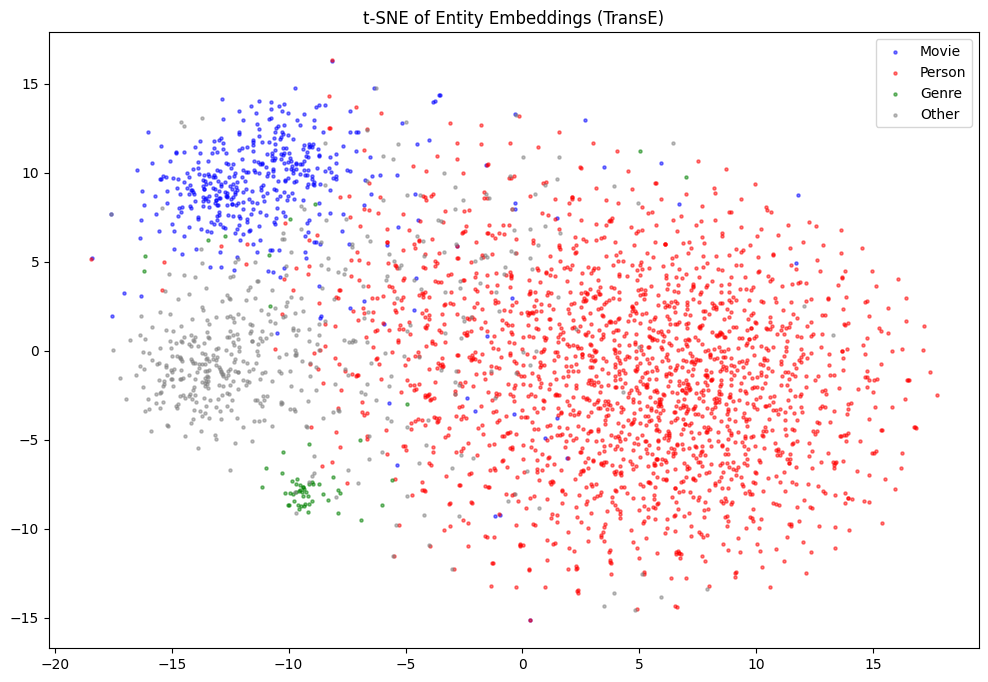

In [37]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Apply t-SNE to the first 3,000 entities (using too many will slow things down)
n_sample = 3000
sample_embs = entity_embs[:n_sample]

# Determine the type of each entity
from rdflib.namespace import RDF

MVO = "http://moviekg.local/ontology/"

def get_entity_type(uri):
    uri_ref = URIRef(uri)
    if (uri_ref, RDF.type, URIRef(MVO + "Movie")) in g:
        return "Movie"
    elif (uri_ref, RDF.type, URIRef(MVO + "Person")) in g:
        return "Person"
    elif (uri_ref, RDF.type, URIRef(MVO + "Genre")) in g:
        return "Genre"
    else:
        return "Other"

labels = [get_entity_type(id2entity[i]) for i in range(n_sample)]

# t-SNE dimensionality reduction
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embs_2d = tsne.fit_transform(sample_embs)
print("Done!")

# Plot
colors = {"Movie": "blue", "Person": "red", "Genre": "green", "Other": "gray"}
plt.figure(figsize=(12, 8))
for entity_type, color in colors.items():
    mask = [l == entity_type for l in labels]
    plt.scatter(embs_2d[mask, 0], embs_2d[mask, 1], 
                c=color, label=entity_type, alpha=0.5, s=5)

plt.legend()
plt.title("t-SNE of Entity Embeddings (TransE)")
plt.savefig("tsne.png", dpi=150)
plt.show()

t-SNE Visualization Results and Interpretation:

Genre (green) forms a tight and compact cluster in the lower-left region, indicating that the model effectively captures the semantic characteristics of genre entities.
Movie (blue) entities are generally concentrated in the upper-right area, showing a moderate clustering effect.
Person (red) entities are more dispersed and partially overlap with Other (grey) entities.
Other (grey) entities are the most scattered, reflecting their heterogeneous and less well-defined semantic nature.

6.3

In [38]:
relation_embs = model_full.relation_emb.weight.detach().numpy()
id2relation = {v: k for k, v in relation2id.items()}

print("Relation Embeddings")
for i, rel in id2relation.items():
    rel_name = rel.split("/")[-1].split("#")[-1]
    norm = np.linalg.norm(relation_embs[i])
    print(f"{rel_name:30s} norm: {norm:.4f}")

Relation Embeddings
hasActor                       norm: 6.1379
hasDirector                    norm: 7.7530
hasGenre                       norm: 10.2677
hasProducer                    norm: 7.5957
hasScreenwriter                norm: 7.7962
originCountry                  norm: 6.1525
originalLanguage               norm: 6.6277
producedBy                     norm: 7.8132
type                           norm: 9.6891
domain                         norm: 6.7514
range                          norm: 7.3757
sameAs                         norm: 6.2971


ex8

In [39]:
#SWRL Embedding
# Find MultitalentedDirector
from rdflib import Graph, URIRef, RDFS
MVO_NS = "http://moviekg.local/ontology/"

multitalented = set()
for movie in g.subjects(URIRef("http://www.w3.org/1999/02/22-rdf-syntax-ns#type"), 
                          URIRef(MVO_NS + "Movie")):
    directors   = set(g.objects(movie, URIRef(MVO_NS + "hasDirector")))
    screenwriters = set(g.objects(movie, URIRef(MVO_NS + "hasScreenwriter")))
    overlap = directors & screenwriters
    multitalented.update(overlap)

print(f"MultitalentedDirector found by SWRL rule: {len(multitalented)}")
for p in list(multitalented)[:5]:
    label = g.value(p, RDFS.label)
    print(f"  {label}")

# Embedding: Vector similarity of hasDirector and hasScreenwriter
dir_id= relation2id.get("http://moviekg.local/ontology/hasDirector")
screen_id = relation2id.get("http://moviekg.local/ontology/hasScreenwriter")

if dir_id and screen_id:
    dir_emb    = relation_embs[dir_id]
    screen_emb = relation_embs[screen_id]
    from sklearn.metrics.pairwise import cosine_similarity
    sim = cosine_similarity(dir_emb.reshape(1,-1), screen_emb.reshape(1,-1))[0][0]
    print(f"\nCosine similarity(hasDirector, hasScreenwriter): {sim:.4f}")
    print("If high, embedding agrees with the SWRL rule")

MultitalentedDirector found by SWRL rule: 41
  Joss Whedon
  Bong Joon-ho
  Rich Moore
  Zvonimir Berković
  Joe Carnahan

Cosine similarity(hasDirector, hasScreenwriter): 0.2795
→ If high, embedding agrees with the SWRL rule
